In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
import umap  

Loaded 61724 fine-tuned embeddings (each 128-D).


In [7]:
base_dir = "/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/mmp_optimized_test"

proj_emb_path    = f"{base_dir}/projected_embeddings.npy"
smiles_list_path = f"{base_dir}/embedding_smiles.txt"


pos_csv = "/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_distinct.csv"
neg_csv = "/Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_neg_distinct.csv"


proj_emb = np.load(proj_emb_path)   # shape: (N_all, 128)
with open(smiles_list_path, "r") as f:
    smiles_list = [line.strip() for line in f]
    
if len(smiles_list) != proj_emb.shape[0]:
    raise ValueError(
        f"Mismatch: {len(smiles_list)} SMILES vs {proj_emb.shape[0]} rows in projected_embeddings.npy"
    )

# Build lookup: smiles_to_idx[s] = i  →  row i of proj_emb is that SMILES
smiles_to_idx = {s: i for i, s in enumerate(smiles_list)}

print(f"Loaded {proj_emb.shape[0]} fine-tuned embeddings (each 128-D).")


def load_finetuned_embeddings_for_pairs(csv_path):
    """
    Given a path to CSV (no header) whose 1st and 3rd columns are SMILES for item_1 and item_2,
    return:
      - emb_1: a NumPy array of shape (n_valid_pairs, 128)
      - emb_2: a NumPy array of shape (n_valid_pairs, 128)
      - valid_pairs: list of (sm1, sm2) that were found in smiles_to_idx
    """
    df = pd.read_csv(csv_path, header=None)
    smiles_a = df.iloc[:, 0].astype(str).tolist()
    smiles_b = df.iloc[:, 2].astype(str).tolist()
    
    emb_list_1 = []
    emb_list_2 = []
    valid_pairs = []
    
    for a, b in zip(smiles_a, smiles_b):
        if a in smiles_to_idx and b in smiles_to_idx:
            emb_list_1.append(proj_emb[smiles_to_idx[a]])
            emb_list_2.append(proj_emb[smiles_to_idx[b]])
            valid_pairs.append((a, b))
        else:
            # skip pairs if either SMILES not found in embedding map
            continue
    
    if len(valid_pairs) == 0:
        raise ValueError(f"No valid pairs found in {csv_path}")
    
    emb_1 = np.stack(emb_list_1, axis=0)  # shape = (n_valid, 128)
    emb_2 = np.stack(emb_list_2, axis=0)  # shape = (n_valid, 128)
    
    print(f"  Loaded {len(valid_pairs)} valid pairs from {csv_path}.")
    return emb_1, emb_2, valid_pairs

def visualize_finetuned_embeddings(csv_path, method="pca"):
    """
    csv_path: full path to a matched-pairs CSV (e.g. pos_csv or neg_csv).
    method: 'pca' or 'umap'
    
    We will:
      1) Load embeddings for item1 & item2 (both shape (n_pairs,128))
      2) Stack → (2·n_pairs, 128)
      3) Reducer.fit_transform(...) → (2·n_pairs, 2)
      4) Split the result → two (n_pairs, 2) arrays
      5) Scatter plot item1 (blue) vs item2 (red), plus light grey lines.
    """
    emb_1, emb_2, valid_pairs = load_finetuned_embeddings_for_pairs(csv_path)
    n = emb_1.shape[0]
    
    # Choose dimensionality reducer
    if method.lower() == "pca":
        reducer = PCA(n_components=2, random_state=42)
    elif method.lower() == "umap":
        reducer = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # 1) Combine
    combined = np.vstack([emb_1, emb_2])   # shape = (2n, 128)
    reduced = reducer.fit_transform(combined)  # → (2n, 2)
    
    # 2) Split back
    reduced_1 = reduced[:n]
    reduced_2 = reduced[n:]
    
    # 3) Plot
    plt.figure(figsize=(8, 6))
    # Plot item1 (blue) and item2 (red)
    plt.scatter(
        reduced_1[:, 0], reduced_1[:, 1],
        c="tab:blue", alpha=0.6, s=10, label="Item 1"
    )
    plt.scatter(
        reduced_2[:, 0], reduced_2[:, 1],
        c="tab:red", alpha=0.6, s=10, label="Item 2"
    )
    # Draw lines between each matched pair (limit to first 500 to avoid clutter)
    max_lines = min(500, n)
    for i in range(max_lines):
        x1, y1 = reduced_1[i]
        x2, y2 = reduced_2[i]
        plt.plot([x1, x2], [y1, y2], c="gray", alpha=0.1, linewidth=0.7)
    
    # Title based on filename
    name = os.path.basename(csv_path).replace(".csv", "")
    plt.title(f"Fine-Tuned Embeddings ({method.upper()}) for {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Loaded 61724 fine-tuned embeddings (each 128-D).


In [ ]:
def calculate_finetuned_pair_distances(csv_path):
    """
    Returns:
      - euclid:  np.array shape (n_pairs,), Euclidean distances between item1/item2
      - cosine:  np.array shape (n_pairs,), Cosine similarities between item1/item2
    """
    emb_1, emb_2, valid_pairs = load_finetuned_embeddings_for_pairs(csv_path)
    
    # Euclidean:
    diffs = emb_1 - emb_2                   # (n, 128)
    euclid = np.linalg.norm(diffs, axis=1)  # (n,)
    
    # Cosine similarity = 1 - cosine_distance
    # Use sklearn’s pairwise cosine_distances on 2×128 row → (2×2) submatrix,
    # but we can do it in a vectorized way:
    #   sim(a, b) = (a·b) / (||a|| ||b||)
    numer = np.sum(emb_1 * emb_2, axis=1)
    denom = np.linalg.norm(emb_1, axis=1) * np.linalg.norm(emb_2, axis=1)
    cosine = numer / (denom + 1e-12)   # (n,)
    
    return euclid, cosine


def plot_finetuned_distance_distributions(pos_csv, neg_csv):
    """
    For the pair CSVs (positive vs negative), compute and plot:
      - histogram of Euclidean distances
      - histogram of Cosine similarities
    """
    # Positive:
    euclid_pos, cosine_pos   = calculate_finetuned_pair_distances(pos_csv)
    # Negative:
    euclid_neg, cosine_neg   = calculate_finetuned_pair_distances(neg_csv)
    
    # Plot Euclidean histograms
    plt.figure(figsize=(8, 5))
    plt.hist(euclid_pos, bins=50, alpha=0.7, label="Positive Pairs", color="tab:blue")
    plt.hist(euclid_neg, bins=50, alpha=0.7, label="Negative Pairs", color="tab:orange")
    plt.title("Euclidean Distance Distribution (Fine-Tuned 128-D)")
    plt.xlabel("Euclidean Distance")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Plot Cosine histograms
    plt.figure(figsize=(8, 5))
    plt.hist(cosine_pos, bins=50, alpha=0.7, label="Positive Pairs", color="tab:blue")
    plt.hist(cosine_neg, bins=50, alpha=0.7, label="Negative Pairs", color="tab:orange")
    plt.title("Cosine Similarity Distribution (Fine-Tuned 128-D)")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
def compute_avg_finetuned_distances(csv_path):
    """
    Returns a dict with:
      { 'euclid': mean_euclid, 'cosine': mean_cosine }
    for that CSV of pairs.
    """
    euclid, cosine = calculate_finetuned_pair_distances(csv_path)
    return {
        "euclid": float(np.mean(euclid)),
        "cosine": float(np.mean(cosine))
    }

def compare_positive_negative_finetuned(pos_csv, neg_csv):
    """
    Prints absolute differences in average Euclidean & Cosine between pos vs neg.
    """
    pos_avg = compute_avg_finetuned_distances(pos_csv)
    neg_avg = compute_avg_finetuned_distances(neg_csv)
    
    abs_diff = {
        "euclid": abs(pos_avg["euclid"] - neg_avg["euclid"]),
        "cosine": abs(pos_avg["cosine"] - neg_avg["cosine"])
    }
    print("Average Euclidean (positive):", pos_avg["euclid"])
    print("Average Euclidean (negative):", neg_avg["euclid"])
    print(f"  → |Δ Euclid| = {abs_diff['euclid']:.4f}\n")
    
    print("Average Cosine (positive):", pos_avg["cosine"])
    print("Average Cosine (negative):", neg_avg["cosine"])
    print(f"  → |Δ Cosine| = {abs_diff['cosine']:.4f}")
    
    return pos_avg, neg_avg, abs_diff

def plot_positive_negative_scatter_finetuned(pos_csv, neg_csv):
    """
    Scatter-plot positive_avg vs negative_avg for Euclidean & Cosine,
    with a diagonal y=x line for reference.
    """
    pos_avg, neg_avg, abs_diff = compare_positive_negative_finetuned(pos_csv, neg_csv)
    
    metrics = ["euclid", "cosine"]
    labels  = ["Euclidean", "Cosine"]
    
    plt.figure(figsize=(10, 4))
    for i, m in enumerate(metrics):
        plt.subplot(1, 2, i + 1)
        x = pos_avg[m]
        y = neg_avg[m]
        plt.scatter([x], [y], color="tab:purple", s=100)
        plt.annotate(
            f"{m}\nΔ={abs_diff[m]:.4f}", 
            (x, y), 
            textcoords="offset points", xytext=(5,5)
        )
        mn = min(x, y) - 0.1 * min(x, y)
        mx = max(x, y) + 0.1 * max(x, y)
        plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
        plt.xlabel(f"Positive avg {labels[i]}")
        plt.ylabel(f"Negative avg {labels[i]}")
        plt.title(f"{labels[i]}: Pos vs Neg")
    plt.tight_layout()
    plt.show()


--- PCA on Positive Pairs (fine-tuned) ---
  Loaded 21352 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_distinct.csv.


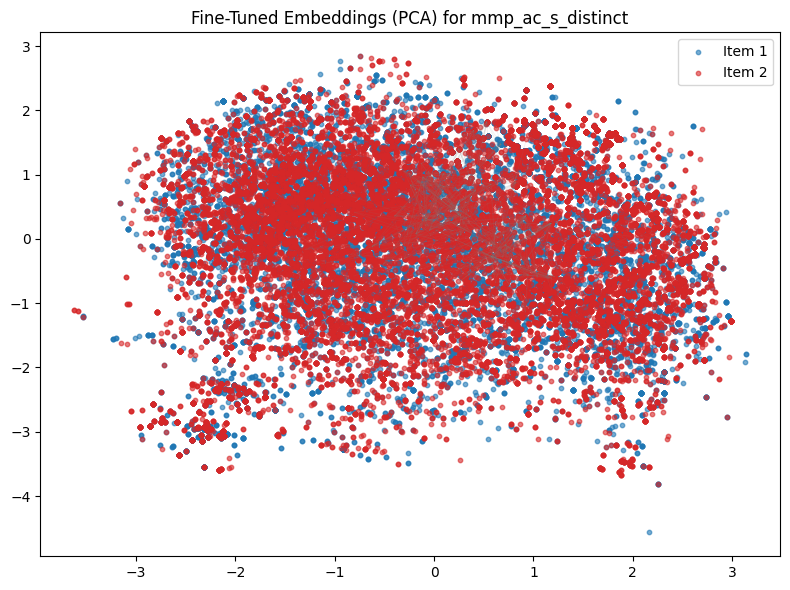


--- UMAP on Positive Pairs (fine-tuned) ---
  Loaded 21352 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_distinct.csv.


/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/

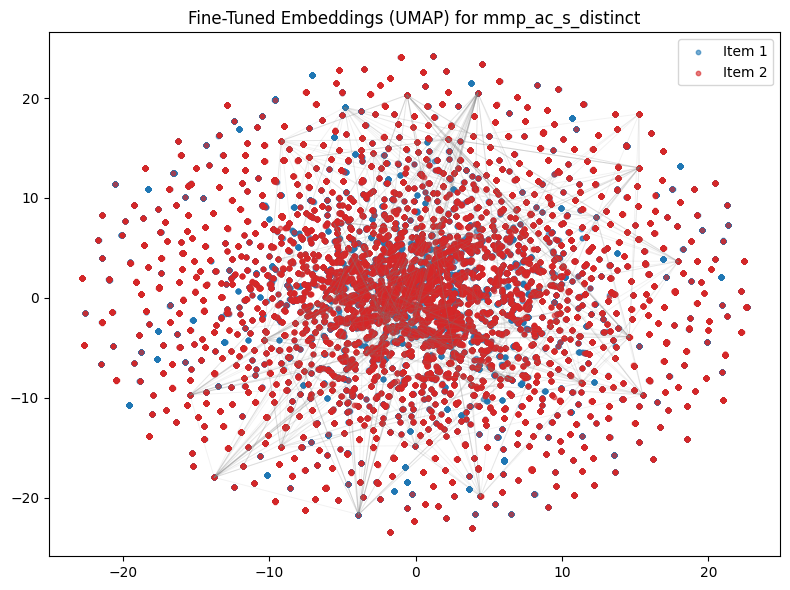


--- PCA on Negative Pairs (fine-tuned) ---


/var/folders/ll/bn78crzd67nc85v6_q6g3k6r0000gn/T/ipykernel_18722/1469944611.py:34: DtypeWarning: Columns (1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, header=None)


  Loaded 423282 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_neg_distinct.csv.


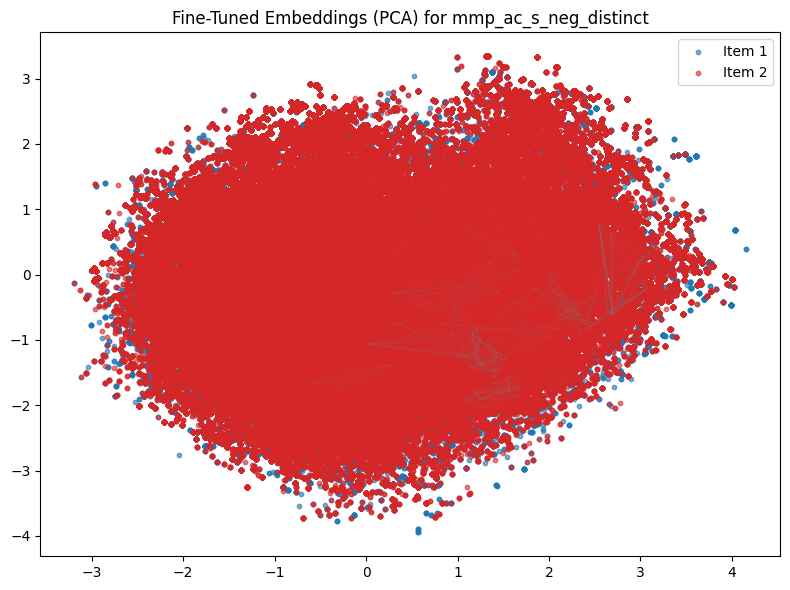


--- UMAP on Negative Pairs (fine-tuned) ---


/var/folders/ll/bn78crzd67nc85v6_q6g3k6r0000gn/T/ipykernel_18722/1469944611.py:34: DtypeWarning: Columns (1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, header=None)


  Loaded 423282 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_neg_distinct.csv.


/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/envs/biomed-multiview/lib/python3.11/site-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/ananya_krishna/Documents/GitHub/biomed-multiview/

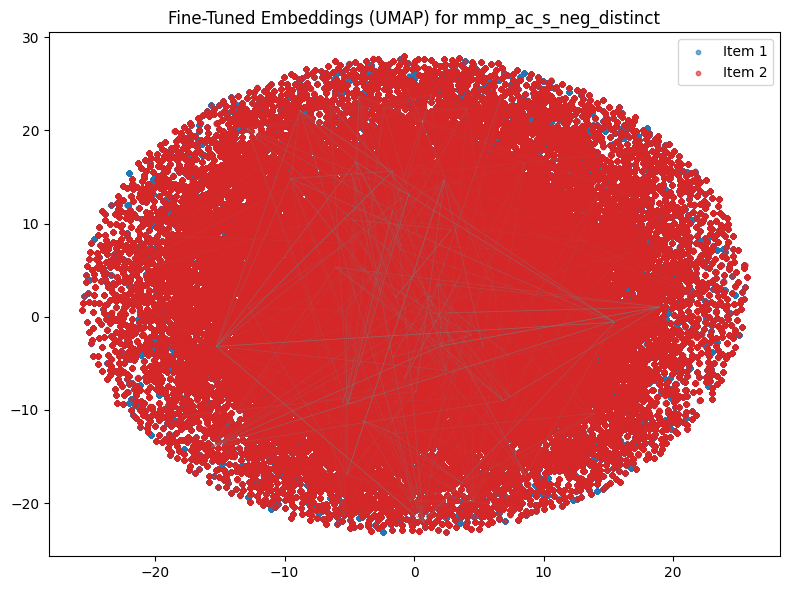


--- Distance Histograms (fine-tuned) ---
  Loaded 21352 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_distinct.csv.


/var/folders/ll/bn78crzd67nc85v6_q6g3k6r0000gn/T/ipykernel_18722/1469944611.py:34: DtypeWarning: Columns (1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, header=None)


  Loaded 423282 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_neg_distinct.csv.

--- Avg Differences (fine-tuned) ---
  Loaded 21352 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_distinct.csv.


/var/folders/ll/bn78crzd67nc85v6_q6g3k6r0000gn/T/ipykernel_18722/1469944611.py:34: DtypeWarning: Columns (1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, header=None)


  Loaded 423282 valid pairs from /Users/ananya_krishna/Documents/GitHub/biomed-multiview/code/biomed-multi-view/notebooks/mmp_ac_s_neg_distinct.csv.
Average Euclidean (positive): 1.5970960855484009
Average Euclidean (negative): 1.3395336866378784
  → |Δ Euclid| = 0.2576

Average Cosine (positive): 0.9028521776199341
Average Cosine (negative): 0.9259028434753418
  → |Δ Cosine| = 0.0231


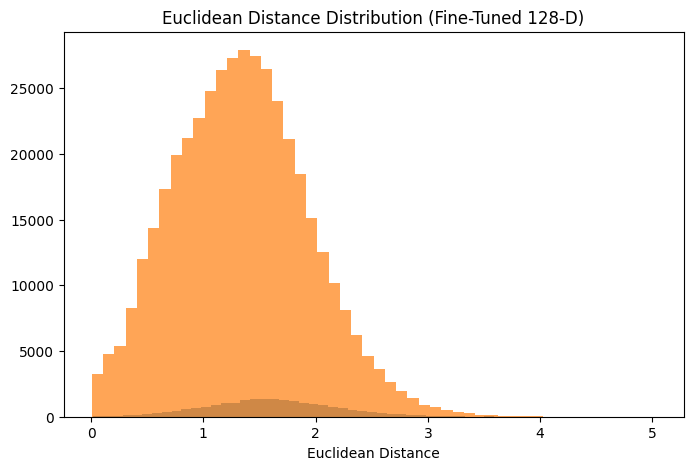

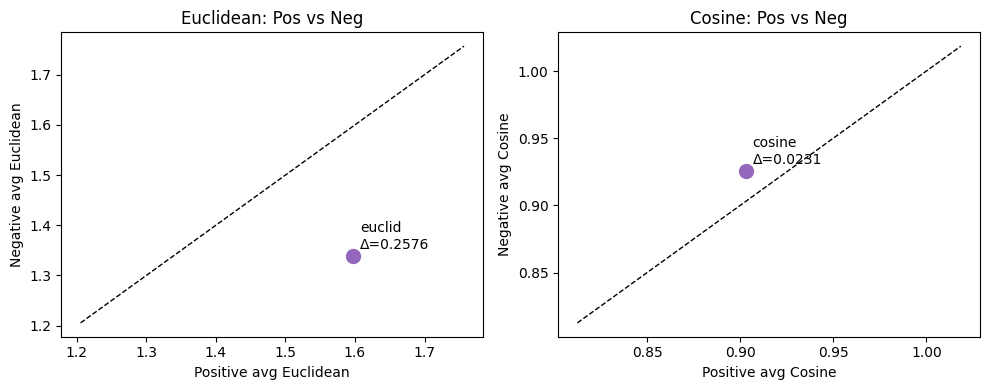

In [10]:
print("\n--- PCA on Positive Pairs (fine-tuned) ---")
visualize_finetuned_embeddings(pos_csv, method="pca")
print("\n--- UMAP on Positive Pairs (fine-tuned) ---")
visualize_finetuned_embeddings(pos_csv, method="umap")
print("\n--- PCA on Negative Pairs (fine-tuned) ---")
visualize_finetuned_embeddings(neg_csv, method="pca")
print("\n--- UMAP on Negative Pairs (fine-tuned) ---")
visualize_finetuned_embeddings(neg_csv, method="umap")
print("\n--- Distance Histograms (fine-tuned) ---")
plot_finetuned_distance_distributions(pos_csv, neg_csv)
print("\n--- Avg Differences (fine-tuned) ---")
plot_positive_negative_scatter_finetuned(pos_csv, neg_csv)